<a href="https://colab.research.google.com/github/sl007ha/qqq-risk-monitor/blob/main/01_data_features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yfinance pandas-datareader fredapi --quiet

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
from pandas_datareader import data as pdr
from fredapi import Fred
import matplotlib.pyplot as plt
from google.colab import userdata

FRED_API_KEY = userdata.get('FRED_API_KEY')
fred = Fred(api_key=FRED_API_KEY)

print("Setup OK")

Setup OK


In [3]:
# NDX = 纳斯达克 100 指数（QQQ 跟踪它）
ndx = yf.download('^NDX', start='1985-10-01', end='2025-12-31', auto_adjust=True)
ndx = ndx[['Close']].copy()
ndx.columns = ['ndx_close']

# 转成月末数据（我们的预测频率是月度）
ndx_m = ndx.resample('ME').last()  # 'ME' = Month End

print(ndx_m.head())
print(ndx_m.tail())
print(f"数据行数：{len(ndx_m)}")

[*********************100%***********************]  1 of 1 completed

             ndx_close
Date                  
1985-10-31  115.480003
1985-11-30  126.059998
1985-12-31  132.294998
1986-01-31  132.925003
1986-02-28  140.425003
               ndx_close
Date                    
2025-08-31  23415.419922
2025-09-30  24679.990234
2025-10-31  25858.130859
2025-11-30  25434.890625
2025-12-31  25462.560547
数据行数：483


In [4]:
# 用日频数据算 200 日均线，再 resample 到月末
ndx_d = yf.download('^NDX', start='1985-01-01', end='2025-12-31', auto_adjust=True)
ndx_d = ndx_d[['Close']].copy()
ndx_d.columns = ['ndx_close']

ndx_d['ma200'] = ndx_d['ndx_close'].rolling(200).mean()
ndx_d['dist_200dma'] = (ndx_d['ndx_close'] / ndx_d['ma200']) - 1

# 月末快照
features = ndx_d[['dist_200dma']].resample('ME').last()
print(features.tail())

[*********************100%***********************]  1 of 1 completed

            dist_200dma
Date                   
2025-08-31     0.099035
2025-09-30     0.140637
2025-10-31     0.171801
2025-11-30     0.135357
2025-12-31     0.112235


In [5]:
ndx_m['tsmom_12m'] = ndx_m['ndx_close'].pct_change(12)
features['tsmom_12m'] = ndx_m['tsmom_12m']
print(features.tail())

            dist_200dma  tsmom_12m
Date                              
2025-08-31     0.099035   0.196212
2025-09-30     0.140637   0.230266
2025-10-31     0.171801   0.300029
2025-11-30     0.135357   0.215215
2025-12-31     0.112235   0.211801


In [7]:
# 估值代理：当前价相对过去 10 年（120 个月）均值的偏离
ndx_m['valuation_proxy'] = (ndx_m['ndx_close'] / ndx_m['ndx_close'].rolling(120).mean()) - 1
features['valuation_proxy'] = ndx_m['valuation_proxy']

In [8]:
yc = fred.get_series('T10Y3M', observation_start='1985-01-01')
yc = yc.resample('ME').last()
features['yc_10y3m'] = yc
print(features.tail())

            dist_200dma  tsmom_12m  valuation_proxy  yc_10y3m
Date                                                         
2025-08-31     0.099035   0.196212         1.089264      0.00
2025-09-30     0.140637   0.230266         1.169036      0.14
2025-10-31     0.171801   0.300029         1.237817      0.22
2025-11-30     0.135357   0.215215         1.168704      0.14
2025-12-31     0.112235   0.211801         1.139340      0.51


In [9]:
# FRED 上 ISM Manufacturing PMI 的 series id 是 'NAPM'，但已经停止更新（许可问题）
# 替代：用 'MANEMP'（制造业就业），相关性高
manemp = fred.get_series('MANEMP', observation_start='1985-01-01')
manemp_yoy = manemp.pct_change(12) * 100  # 同比变化
manemp_yoy = manemp_yoy.resample('ME').last()
features['mfg_emp_yoy'] = manemp_yoy

dist_200dma          9
tsmom_12m           12
valuation_proxy    119
yc_10y3m             0
mfg_emp_yoy          3
dtype: int64
清洗前：483 行
清洗后：364 行
起始日期：1995-09-30 00:00:00


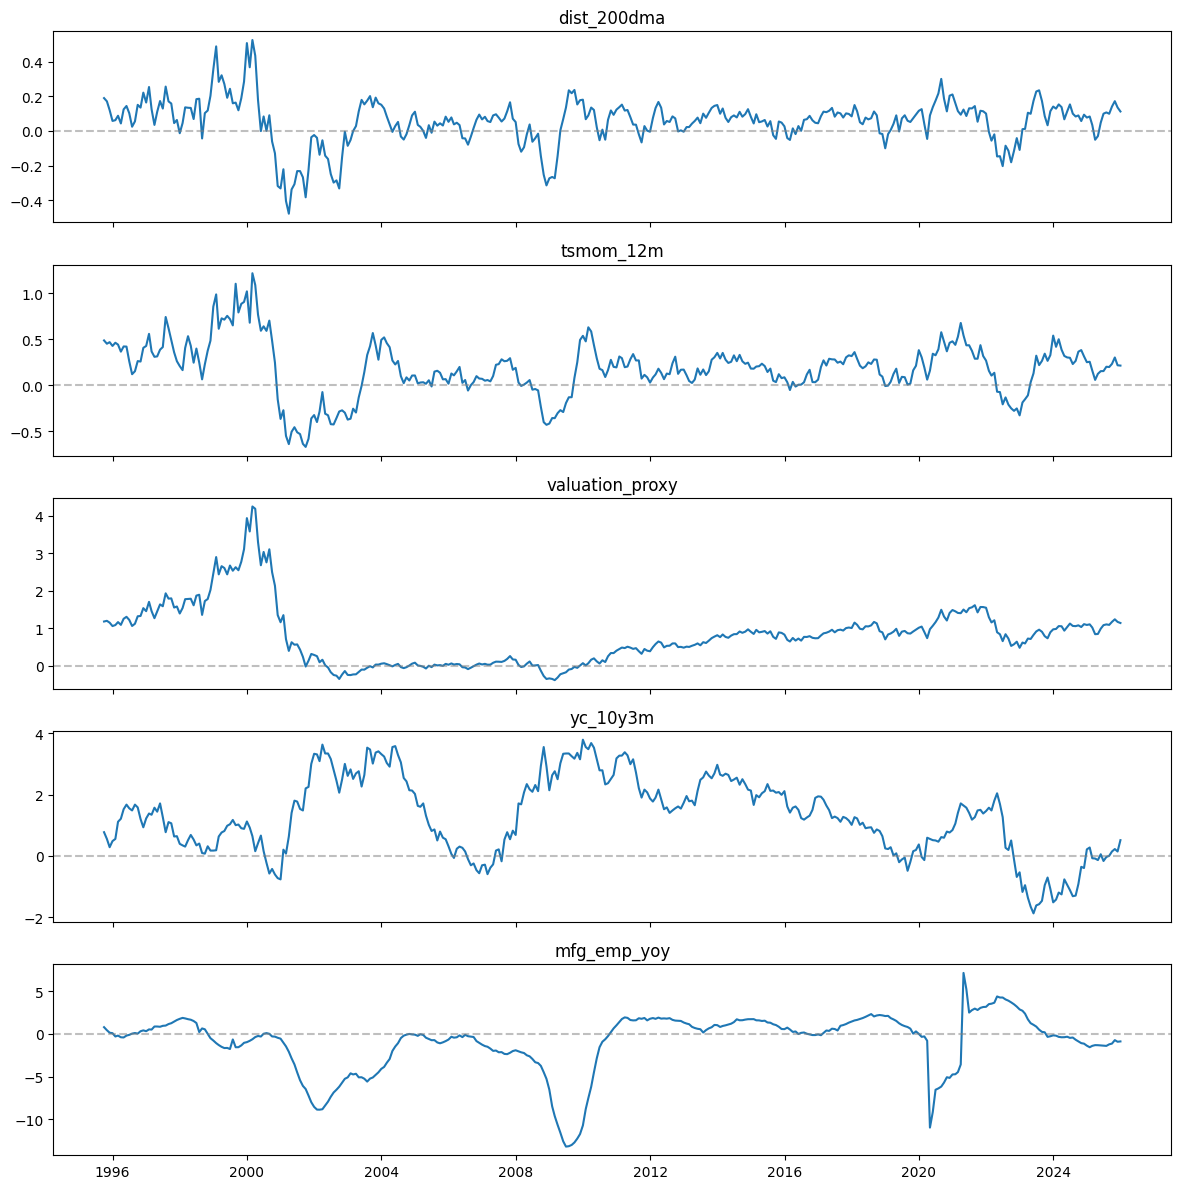

In [10]:
# 看看有多少缺失值
print(features.isna().sum())

# 删除任何特征缺失的行
features_clean = features.dropna()
print(f"清洗前：{len(features)} 行")
print(f"清洗后：{len(features_clean)} 行")
print(f"起始日期：{features_clean.index[0]}")

# 保存到 Colab 临时空间
features_clean.to_csv('features_mvp.csv')

# 同时画图看看每个特征的样子
fig, axes = plt.subplots(5, 1, figsize=(12, 12), sharex=True)
for i, col in enumerate(features_clean.columns):
    axes[i].plot(features_clean.index, features_clean[col])
    axes[i].set_title(col)
    axes[i].axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()